#### [HMDA dataset](https://ffiec.cfpb.gov/data-browser/data/2022?category=counties&items=47037)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import statsmodels.formula.api as smf
import statsmodels.api as sm

##### Read in the data

In [2]:
# read in the data
hmda_2022 = pd.read_csv('../data/msamd_12060_2022.csv') 
hmda_2023 = pd.read_csv('../data/msamd_12060_2023.csv')

C:\Users\Cat\AppData\Local\Temp\ipykernel_20492\2718690324.py:2: DtypeWarning: Columns (22,23,24,26,27,28,29,30,31,32,33,38,43,44) have mixed types. Specify dtype option on import or set low_memory=False.
  hmda_2022 = pd.read_csv('../data/msamd_12060_2022.csv')
C:\Users\Cat\AppData\Local\Temp\ipykernel_20492\2718690324.py:3: DtypeWarning: Columns (22,23,24,26,27,28,29,30,31,32,33,38,43,44) have mixed types. Specify dtype option on import or set low_memory=False.
  hmda_2023 = pd.read_csv('../data/msamd_12060_2023.csv')


In [3]:
hmda_2022.head(2)

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,denial_reason-2,denial_reason-3,denial_reason-4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units
0,2022,549300FGXN1K3HLB1R50,12060,GA,13135.0,1.313505e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,NaN,NaN,NaN,4582,90.27,95700,59.25,693,1364,26
1,2022,549300FGXN1K3HLB1R50,12060,GA,13113.0,1.311314e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,5777,67.49,95700,117.88,1806,2070,29


In [4]:
len(hmda_2022.columns)

99

In [5]:
# https://stackoverflow.com
# number of non-NaN values in first column
hmda_2022[hmda_2022.columns[0]].count()

np.int64(378284)

##### Remove all values that do not reflect approved and accepted = 1, or denied = 3

In [6]:
# remove all values that do not reflect approved, denied, or approved but not accepted
# Description: The action taken on the covered loan or application
# Values:
# 1 - Loan originated
# 2 - Application approved but not accepted
# 3 - Application denied
# 4 - Application withdrawn by applicant
# 5 - File closed for incompleteness
# 6 - Purchased loan
# 7 - Preapproval request denied
# 8 - Preapproval request approved but not accepted

list_of_values_to_keep = [1,3]

hmda_2022_action_taken = hmda_2022[hmda_2022['action_taken'].isin(list_of_values_to_keep)]
hmda_2022_action_taken['action_taken'].unique()

array([1, 3])

In [7]:
hmda_2022_action_taken['approved_originated_or_denied'] = hmda_2022_action_taken['action_taken']

C:\Users\Cat\AppData\Local\Temp\ipykernel_20492\203439602.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hmda_2022_action_taken['approved_originated_or_denied'] = hmda_2022_action_taken['action_taken']


In [8]:
hmda_2022_action_taken['approved_originated_or_denied'] = hmda_2022_action_taken['approved_originated_or_denied'].replace({1 : 1, 3 : 0})

C:\Users\Cat\AppData\Local\Temp\ipykernel_20492\1368484208.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hmda_2022_action_taken['approved_originated_or_denied'] = hmda_2022_action_taken['approved_originated_or_denied'].replace({1 : 1, 3 : 0})


In [9]:
# https://stackoverflow.com
# number of non-NaN values in first column
hmda_2022_action_taken[hmda_2022_action_taken.columns[0]].count()

np.int64(245118)

##### Remove not applicable (could include applicants with little to no credit and exempt institutions) to eliminate legal entities like corporations etc from being included in the data instead of individuals

In [10]:
# remove not applicable (could include applicants with little to no credit) and exempt institutions
# to eliminate legal entitities like corporations etc from being included in the data instead of individuals

# Description: The name and version of the credit scoring model used to generate the credit score, or scores, relied on in making the credit decision
# Values:
# 1 - Equifax Beacon 5.0
# 2 - Experian Fair Isaac
# 3 - FICO Risk Score Classic 04
# 4 - FICO Risk Score Classic 98
# 5 - VantageScore 2.0
# 6 - VantageScore 3.0
# 7 - More than one credit scoring model
# 8 - Other credit scoring model
# 9 - Not applicable
# 1111 - Exempt

list_of_values_to_keep = [1,2,3,4,5,6,7,8]

hmda_2022_credit_score_app = hmda_2022_action_taken[hmda_2022_action_taken['applicant_credit_score_type'].isin(list_of_values_to_keep)]
hmda_2022_credit_score_app['applicant_credit_score_type'].unique()

array([2, 1, 3, 8, 7, 6, 4, 5])

In [11]:
# https://stackoverflow.com
# number of non-NaN values in first column
hmda_2022_credit_score_app[hmda_2022_credit_score_app.columns[0]].count()

np.int64(214830)

##### Remove not applicable (could include applicants with little to no credit and exempt institutions) to eliminate legal entities like corporations etc from being included in the data instead of individuals`

In [12]:
# remove not applicable (could include applicants with little to no credit and exempt institutions)
# to eliminate legal entitities like corporations etc from being included in the data instead of individuals

# Description: The name and version of the credit scoring model used to generate the credit score, or scores, relied on in making the credit decision
# Values:
# 1 - Equifax Beacon 5.0
# 2 - Experian Fair Isaac
# 3 - FICO Risk Score Classic 04
# 4 - FICO Risk Score Classic 98
# 5 - VantageScore 2.0
# 6 - VantageScore 3.0
# 7 - More than one credit scoring model
# 8 - Other credit scoring model
# 9 - Not applicable
# 10 - No co-applicant
# 11 – FICO Score 9
# 12 – FICO Score 8
# 13 – FICO Score 10
# 14 – FICO Score 10T
# 15 - VantageScore 4.0
# 1111 - Exempt

list_of_values_to_keep = [1,2,3,4,5,6,7,8,10,11,12,13,14,15]

hmda_2022_credit_score_co = hmda_2022_credit_score_app[hmda_2022_credit_score_app['co-applicant_credit_score_type'].isin(list_of_values_to_keep)]
hmda_2022_credit_score_co['co-applicant_credit_score_type'].unique()

array([10,  3,  1,  2,  8,  6,  4,  7,  5, 11])

In [13]:
# https://stackoverflow.com
# number of non-NaN values in first column
hmda_2022_credit_score_co[hmda_2022_credit_score_co.columns[0]].count()

np.int64(174925)

##### Inspect all columns

In [14]:
# hmda_2022_credit_score_co.columns.tolist()

##### Create a unique index for each application/row

In [15]:
# create a unique number for every application as an ID column of sorts
hmda_2022_credit_score_co["unique_id"] = range(len(hmda_2022_credit_score_co))

C:\Users\Cat\AppData\Local\Temp\ipykernel_20492\2598958234.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hmda_2022_credit_score_co["unique_id"] = range(len(hmda_2022_credit_score_co))


##### Coerce to numeric the loan_to_value_ratio 

In [16]:
hmda_2022_credit_score_co['loan_to_value_ratio'].dtype
# hmda_ohe_dr['loan_to_value_ratio'].value_counts()
hmda_2022_credit_score_co['loan_to_value_ratio'] = pd.to_numeric(hmda_2022_credit_score_co['loan_to_value_ratio'], errors='coerce')
hmda_2022_credit_score_co['loan_to_value_ratio'].dtype
hmda_2022_credit_score_co['loan_to_value_ratio'].value_counts()

C:\Users\Cat\AppData\Local\Temp\ipykernel_20492\3114287239.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hmda_2022_credit_score_co['loan_to_value_ratio'] = pd.to_numeric(hmda_2022_credit_score_co['loan_to_value_ratio'], errors='coerce')


loan_to_value_ratio
80.000     17823
95.000     11122
96.500      9888
90.000      6193
100.000     6051
           ...  
70.126         1
60.928         1
58.984         1
81.997         1
81.060         1
Name: count, Length: 38100, dtype: int64

##### Make sure property_value is the correct data type

In [17]:
hmda_2022_credit_score_co['property_value'].dtype
hmda_2022_credit_score_co['property_value'] = pd.to_numeric(hmda_2022_credit_score_co['property_value'], errors='coerce')
hmda_2022_credit_score_co['property_value'].dtype
hmda_2022_credit_score_co['property_value'].value_counts()

C:\Users\Cat\AppData\Local\Temp\ipykernel_20492\1753944827.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hmda_2022_credit_score_co['property_value'] = pd.to_numeric(hmda_2022_credit_score_co['property_value'], errors='coerce')


property_value
305000.0     6084
355000.0     5435
255000.0     5108
325000.0     4996
285000.0     4834
             ... 
6835000.0       1
4335000.0       1
2565000.0       1
6655000.0       1
2485000.0       1
Name: count, Length: 406, dtype: int64

##### Make sure income is the correct data type

In [18]:
hmda_2022_credit_score_co['income'].dtype

dtype('float64')

##### Make sure interest_rate is the correct data type

In [19]:
hmda_2022_credit_score_co['interest_rate'].dtype
hmda_2022_credit_score_co['interest_rate'] = pd.to_numeric(hmda_2022_credit_score_co['interest_rate'], errors='coerce')
hmda_2022_credit_score_co['interest_rate'].dtype
hmda_2022_credit_score_co['interest_rate'].value_counts()

C:\Users\Cat\AppData\Local\Temp\ipykernel_20492\3821468937.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hmda_2022_credit_score_co['interest_rate'] = pd.to_numeric(hmda_2022_credit_score_co['interest_rate'], errors='coerce')


interest_rate
3.750    4534
3.875    4441
4.750    4421
5.250    4124
4.250    3952
         ... 
5.587       1
4.662       1
6.448       1
5.376       1
8.425       1
Name: count, Length: 2341, dtype: int64

##### Make sure rate_spread is the correct data type

In [20]:
hmda_2022_credit_score_co['rate_spread'].dtype
hmda_2022_credit_score_co['rate_spread'] = pd.to_numeric(hmda_2022_credit_score_co['rate_spread'], errors='coerce')
hmda_2022_credit_score_co['rate_spread'].dtype
hmda_2022_credit_score_co['rate_spread'].value_counts()

C:\Users\Cat\AppData\Local\Temp\ipykernel_20492\101179261.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hmda_2022_credit_score_co['rate_spread'] = pd.to_numeric(hmda_2022_credit_score_co['rate_spread'], errors='coerce')


rate_spread
 0.0000    169
 0.1900    156
-0.0600    146
 0.3500    143
 0.1300    142
          ... 
 0.2614      1
 0.1858      1
 0.9694      1
 2.2912      1
 3.8780      1
Name: count, Length: 8661, dtype: int64

#### Filter down further for reverse mortgage

In [21]:
hmda_2022_credit_score_co['reverse_mortgage']

1         2
2         2
3         2
4         2
5         2
         ..
378279    2
378280    2
378281    2
378282    2
378283    2
Name: reverse_mortgage, Length: 174925, dtype: int64

In [22]:
hmda_2022_credit_score_co = hmda_2022_credit_score_co[hmda_2022_credit_score_co['reverse_mortgage'] == 2]

In [23]:
hmda_2022_credit_score_co['not_reverse_mortgage'] = hmda_2022_credit_score_co['reverse_mortgage']

In [24]:
hmda_2022_credit_score_co['not_reverse_mortgage'].unique()

array([2])

#### Filter down further open-end_line_of_credit

In [25]:
hmda_2022_credit_score_co = hmda_2022_credit_score_co[hmda_2022_credit_score_co['open-end_line_of_credit'] == 2]

#### Filter down further business_or_commercial_purpose

In [26]:
hmda_2022_credit_score_co = hmda_2022_credit_score_co[hmda_2022_credit_score_co['business_or_commercial_purpose'] == 2]

#### Separate out single family homes

In [27]:
hmda_2022_credit_score_co = hmda_2022_credit_score_co[hmda_2022_credit_score_co['total_units'] == 1]

In [28]:
hmda_2022_credit_score_co['single_family_homes'] = hmda_2022_credit_score_co['total_units']

In [29]:
hmda_2022_credit_score_co['single_family_homes']

1         1
2         1
3         1
4         1
5         1
         ..
378279    1
378280    1
378281    1
378282    1
378283    1
Name: single_family_homes, Length: 30489, dtype: object

#### Separate out home purchase vs. refinancing or home improvement

In [30]:
hmda_2022_credit_score_co = hmda_2022_credit_score_co[hmda_2022_credit_score_co['loan_purpose'] == 1]

In [31]:
hmda_2022_credit_score_co['home_purchase'] = hmda_2022_credit_score_co['loan_purpose']

In [32]:
hmda_2022_credit_score_co['home_purchase']

9         1
15        1
21        1
26        1
29        1
         ..
378260    1
378265    1
378269    1
378272    1
378276    1
Name: home_purchase, Length: 10584, dtype: int64

#### Filter down to principal residence occupancy type

In [33]:
# occupancy_type
# Description: Occupancy type for the dwelling
# Values:
# 1 - Principal residence
# 2 - Second residence
# 3 - Investment property

In [34]:
hmda_2022_credit_score_co = hmda_2022_credit_score_co[hmda_2022_credit_score_co['occupancy_type'] == 1]

In [35]:
hmda_2022_credit_score_co['principal_residence'] = hmda_2022_credit_score_co['occupancy_type']

In [36]:
hmda_2022_credit_score_co['principal_residence']

9         1
15        1
21        1
26        1
29        1
         ..
378260    1
378265    1
378269    1
378272    1
378276    1
Name: principal_residence, Length: 10165, dtype: int64

##### Scale ffiec_msa_md_median_family_income

In [37]:
hmda_2022_credit_score_co['ffiec_msa_md_median_family_income_scaled'] = hmda_2022_credit_score_co['ffiec_msa_md_median_family_income'] / 1000

In [38]:
hmda_2022_credit_score_co['ffiec_msa_md_median_family_income_scaled']

9         95.7
15        95.7
21        95.7
26        95.7
29        95.7
          ... 
378260    95.7
378265    95.7
378269    95.7
378272    95.7
378276    95.7
Name: ffiec_msa_md_median_family_income_scaled, Length: 10165, dtype: float64

##### Scale loan_amount

In [39]:
hmda_2022_credit_score_co['loan_amount_scaled'] = hmda_2022_credit_score_co['loan_amount'] / 1000

In [40]:
hmda_2022_credit_score_co['loan_amount_scaled']

9         485.0
15        265.0
21        305.0
26        345.0
29        245.0
          ...  
378260    255.0
378265    385.0
378269    525.0
378272    465.0
378276    365.0
Name: loan_amount_scaled, Length: 10165, dtype: float64

##### Scale property_value

In [41]:
hmda_2022_credit_score_co['property_value_scaled'] = hmda_2022_credit_score_co['property_value'] / 1000

In [42]:
hmda_2022_credit_score_co['property_value_scaled']

9         525.0
15        275.0
21        325.0
26        375.0
29        305.0
          ...  
378260    525.0
378265    375.0
378269    565.0
378272    495.0
378276    405.0
Name: property_value_scaled, Length: 10165, dtype: float64

## Converting categorical data into numeric for the purpose of running a logistic regression

### AUS Automated Underwriting System

##### Melt the AUS columns into a smaller df to OHE those columns

In [43]:
# melting data into smaller df to ohe it
hmda_melted_aus = hmda_2022_credit_score_co.melt(
    id_vars="unique_id", 
    value_vars=["aus-1", "aus-2", "aus-3", "aus-4", "aus-5"],
    var_name="aus_types", 
    value_name="aus_values"
) 

In [44]:
# inspect dataset values
hmda_melted_aus.head(2)

,unique_id,aus_types,aus_values
0,8,aus-1,2.0
1,12,aus-1,3.0


In [45]:
# inspect values in columns
hmda_melted_aus["aus_values"].unique()

array([ 2.,  3.,  1.,  6.,  4.,  5., nan])

##### Fill in NaNs with 0s and change it to an integer not a float

In [46]:
# fill NaNs with zeroes and change the data type to integer instead of float
hmda_melted_aus["aus_values"] = hmda_melted_aus["aus_values"].fillna(0).astype(int)

In [47]:
hmda_melted_aus.head(2)

,unique_id,aus_types,aus_values
0,8,aus-1,2
1,12,aus-1,3


##### OneHotEncoder

In [48]:
# use OneHotEncoder
transformed = OneHotEncoder(sparse_output=False).set_output(transform="pandas")

# fit and transform the specific column
encoded_df = transformed.fit_transform(hmda_melted_aus[["aus_values"]])

# combine the encoded columns back with the original df
hmda_ohe_aus = pd.concat([hmda_melted_aus.drop(columns=["aus_values"]), encoded_df], axis=1)

In [49]:
hmda_ohe_aus.head(2) 

,unique_id,aus_types,aus_values_0,aus_values_1,aus_values_2,aus_values_3,aus_values_4,aus_values_5,aus_values_6
0,8,aus-1,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,12,aus-1,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [50]:
hmda_ohe_aus.columns

Index(['unique_id', 'aus_types', 'aus_values_0', 'aus_values_1',
       'aus_values_2', 'aus_values_3', 'aus_values_4', 'aus_values_5',
       'aus_values_6'],
      dtype='object')

##### Drop unnecessary columns 

In [51]:
hmda_ohe_aus = hmda_ohe_aus.drop(columns=["aus_values_0", "aus_types"])

##### Group by the unique_id column, add those values together, and reset the index

In [52]:
# group by the unique_id column, sum those values together, and reset the index
auses = hmda_ohe_aus.groupby("unique_id").sum().reset_index()

In [53]:
# inspect values in columns
auses["aus_values_4"].unique()

array([0., 1.])

##### make aus_columns integers instead of floats

In [54]:
# make aus_columns integers instead of floats
aus_columns = ['aus_values_1', 'aus_values_2', 'aus_values_3', 'aus_values_4', 'aus_values_5', 'aus_values_6']

auses[aus_columns] = auses[aus_columns].fillna(0).astype(int)

In [55]:
auses.head(2)

,unique_id,aus_values_1,aus_values_2,aus_values_3,aus_values_4,aus_values_5,aus_values_6
0,8,0,1,0,0,0,0
1,12,0,0,1,0,0,0


In [56]:
hmda_2022_credit_score_co.head(2)

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,tract_median_age_of_housing_units,approved_originated_or_denied,unique_id,not_reverse_mortgage,single_family_homes,home_purchase,principal_residence,ffiec_msa_md_median_family_income_scaled,loan_amount_scaled,property_value_scaled
9,2022,549300FGXN1K3HLB1R50,12060,GA,13067.0,1.306703e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,40,1,8,2,1,1,1,95.7,485.0,525.0
15,2022,549300FGXN1K3HLB1R50,12060,GA,13121.0,1.312100e+10,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,31,1,12,2,1,1,1,95.7,265.0,275.0


##### Merge the AUS df and the original HMDA df together

In [57]:
hmda_aus = hmda_2022_credit_score_co.merge(auses, on="unique_id")

In [58]:
hmda_aus.head(2)

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,principal_residence,ffiec_msa_md_median_family_income_scaled,loan_amount_scaled,property_value_scaled,aus_values_1,aus_values_2,aus_values_3,aus_values_4,aus_values_5,aus_values_6
0,2022,549300FGXN1K3HLB1R50,12060,GA,13067.0,1.306703e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,1,95.7,485.0,525.0,0,1,0,0,0,0
1,2022,549300FGXN1K3HLB1R50,12060,GA,13121.0,1.312100e+10,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,1,95.7,265.0,275.0,0,0,1,0,0,0


### AE applicant_ethnicity

##### Melt the applicant_ethnicity columns into a smaller df to OHE those columns

In [59]:
# melting data into small df to ohe it
hmda_ae_melted = hmda_aus.melt(
    id_vars="unique_id", 
    value_vars=["applicant_ethnicity-1", "applicant_ethnicity-2", "applicant_ethnicity-3", "applicant_ethnicity-4", "applicant_ethnicity-5"],
    var_name="ae_types", 
    value_name="ae_values"
)

In [60]:
hmda_ae_melted.head(2)

,unique_id,ae_types,ae_values
0,8,applicant_ethnicity-1,2.0
1,12,applicant_ethnicity-1,3.0


In [61]:
hmda_ae_melted["ae_values"].unique()

array([ 2.,  3.,  1., 14., 11., 12., 13., nan])

##### Fill in NaNs with 0s and change it to an integer not a float

In [62]:
hmda_ae_melted["ae_values"] = hmda_ae_melted["ae_values"].fillna(0).astype(int)

In [63]:
hmda_ae_melted.head(2)

,unique_id,ae_types,ae_values
0,8,applicant_ethnicity-1,2
1,12,applicant_ethnicity-1,3


##### OneHotEncode 

In [64]:
# use OneHotEncoder 
transformed = OneHotEncoder(sparse_output=False).set_output(transform="pandas")

# fit and transform the specific column
encoded_df = transformed.fit_transform(hmda_ae_melted[["ae_values"]])

# combine the encoded columns back with the original df
hmda_ae_ohe = pd.concat([hmda_ae_melted.drop(columns=["ae_values"]), encoded_df], axis=1)

In [65]:
hmda_ae_ohe.head(2)#["aus_values_7.0"].unique()#.head(2)

,unique_id,ae_types,ae_values_0,ae_values_1,ae_values_2,ae_values_3,ae_values_11,ae_values_12,ae_values_13,ae_values_14
0,8,applicant_ethnicity-1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,12,applicant_ethnicity-1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [66]:
hmda_ae_ohe.columns.unique()

Index(['unique_id', 'ae_types', 'ae_values_0', 'ae_values_1', 'ae_values_2',
       'ae_values_3', 'ae_values_11', 'ae_values_12', 'ae_values_13',
       'ae_values_14'],
      dtype='object')

##### Drop unnecessary columns 

In [67]:
hmda_ae_ohe = hmda_ae_ohe.drop(columns=["ae_values_0", "ae_types"])

##### Group by the "unique_id" column, add those values together, and reset the index

In [68]:
ae = hmda_ae_ohe.groupby("unique_id").sum().reset_index()#.astype(int)

In [69]:
ae["ae_values_2"].unique()

array([1., 0.])

##### Make ae_columns integers instead of floats

In [70]:
# make ae_columns integers instead of floats
ae_columns = ['ae_values_1', 'ae_values_2', 'ae_values_3', 'ae_values_11', 'ae_values_12','ae_values_13','ae_values_14']

ae[ae_columns] = ae[ae_columns].fillna(0).astype(int)

In [71]:
ae.head(2)

,unique_id,ae_values_1,ae_values_2,ae_values_3,ae_values_11,ae_values_12,ae_values_13,ae_values_14
0,8,0,1,0,0,0,0,0
1,12,0,0,1,0,0,0,0


In [72]:
hmda_aus.head(2)

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,principal_residence,ffiec_msa_md_median_family_income_scaled,loan_amount_scaled,property_value_scaled,aus_values_1,aus_values_2,aus_values_3,aus_values_4,aus_values_5,aus_values_6
0,2022,549300FGXN1K3HLB1R50,12060,GA,13067.0,1.306703e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,1,95.7,485.0,525.0,0,1,0,0,0,0
1,2022,549300FGXN1K3HLB1R50,12060,GA,13121.0,1.312100e+10,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,1,95.7,265.0,275.0,0,0,1,0,0,0


##### Merge together the Applicant Ethnicity df and the HMDA df after ohe for aus

In [73]:
hmda_ae = hmda_aus.merge(ae, on="unique_id")

In [74]:
hmda_ae.head(2)

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,aus_values_4,aus_values_5,aus_values_6,ae_values_1,ae_values_2,ae_values_3,ae_values_11,ae_values_12,ae_values_13,ae_values_14
0,2022,549300FGXN1K3HLB1R50,12060,GA,13067.0,1.306703e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,1,0,0,0,0,0
1,2022,549300FGXN1K3HLB1R50,12060,GA,13121.0,1.312100e+10,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,0,0,0,0,0,1,0,0,0,0


### CAE co-applicant_ethnicity

##### Melt the co-applicant_ethnicity columns into a smaller df to OHE those columns

In [75]:
# melting data into small df to ohe it
hmda_cae_melted = hmda_ae.melt(
    id_vars="unique_id", 
    value_vars=["co-applicant_ethnicity-1", "co-applicant_ethnicity-2", "co-applicant_ethnicity-3", "co-applicant_ethnicity-4", "co-applicant_ethnicity-5"],
    var_name="cae_types", 
    value_name="cae_values"
)

In [76]:
hmda_cae_melted.head(2)

,unique_id,cae_types,cae_values
0,8,co-applicant_ethnicity-1,5.0
1,12,co-applicant_ethnicity-1,5.0


In [77]:
hmda_cae_melted["cae_values"].unique()

array([ 5.,  3.,  2.,  1., 13., 14., nan, 11., 12.])

##### Fill in NaNs with 0s and change it to an integer not a float

In [78]:
hmda_cae_melted["cae_values"] = hmda_cae_melted["cae_values"].fillna(0).astype(int)

In [79]:
hmda_cae_melted.head(2)

,unique_id,cae_types,cae_values
0,8,co-applicant_ethnicity-1,5
1,12,co-applicant_ethnicity-1,5


##### OneHotEncode 

In [80]:
# use OneHotEncoder 
transformed = OneHotEncoder(sparse_output=False).set_output(transform="pandas")

# fit and transform the specific column
encoded_df = transformed.fit_transform(hmda_cae_melted[["cae_values"]])

# combine the encoded columns back with the original df
hmda_cae_ohe = pd.concat([hmda_cae_melted.drop(columns=["cae_values"]), encoded_df], axis=1)

In [81]:
hmda_cae_ohe.head(2)#["aus_values_7.0"].unique()#.head(2)

,unique_id,cae_types,cae_values_0,cae_values_1,cae_values_2,cae_values_3,cae_values_5,cae_values_11,cae_values_12,cae_values_13,cae_values_14
0,8,co-applicant_ethnicity-1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,12,co-applicant_ethnicity-1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [82]:
hmda_cae_ohe.columns.unique()

Index(['unique_id', 'cae_types', 'cae_values_0', 'cae_values_1',
       'cae_values_2', 'cae_values_3', 'cae_values_5', 'cae_values_11',
       'cae_values_12', 'cae_values_13', 'cae_values_14'],
      dtype='object')

##### Drop unnecessary columns 

In [83]:
hmda_cae_ohe = hmda_cae_ohe.drop(columns=["cae_values_0", "cae_types"])

##### Group by the "unique_id" column, add those values together, and reset the index

In [84]:
cae = hmda_cae_ohe.groupby("unique_id").sum().reset_index()#.astype(int)

In [85]:
cae["cae_values_2"].unique()

array([0., 1.])

##### Make cae_columns integers instead of floats

In [86]:
# make cae_columns integers instead of floats
cae_columns = ['cae_values_1', 'cae_values_2', 'cae_values_3', 'cae_values_5', 'cae_values_11','cae_values_12','cae_values_13', 'cae_values_14']

cae[cae_columns] = cae[cae_columns].fillna(0).astype(int)

In [87]:
cae.head(2)

,unique_id,cae_values_1,cae_values_2,cae_values_3,cae_values_5,cae_values_11,cae_values_12,cae_values_13,cae_values_14
0,8,0,0,0,1,0,0,0,0
1,12,0,0,0,1,0,0,0,0


In [88]:
hmda_ae.head(2)

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,aus_values_4,aus_values_5,aus_values_6,ae_values_1,ae_values_2,ae_values_3,ae_values_11,ae_values_12,ae_values_13,ae_values_14
0,2022,549300FGXN1K3HLB1R50,12060,GA,13067.0,1.306703e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,1,0,0,0,0,0
1,2022,549300FGXN1K3HLB1R50,12060,GA,13121.0,1.312100e+10,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,0,0,0,0,0,1,0,0,0,0


##### Merge together the Applicant Ethnicity df and the HMDA df after ohe for aus

In [89]:
hmda_cae = hmda_ae.merge(cae, on="unique_id")

In [90]:
hmda_cae.head(2)

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,ae_values_13,ae_values_14,cae_values_1,cae_values_2,cae_values_3,cae_values_5,cae_values_11,cae_values_12,cae_values_13,cae_values_14
0,2022,549300FGXN1K3HLB1R50,12060,GA,13067.0,1.306703e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,0,1,0,0,0,0
1,2022,549300FGXN1K3HLB1R50,12060,GA,13121.0,1.312100e+10,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,0,0,0,0,0,1,0,0,0,0


### AR applicant_race

##### Melt the applicant_race columns into a smaller df to OHE those columns

In [91]:
# melting data into small df to ohe it
hmda_ar_melted = hmda_cae.melt(
    id_vars="unique_id", 
    value_vars=["applicant_race-1", "applicant_race-2", "applicant_race-3", "applicant_race-4", "applicant_race-5"],
    var_name="ar_types", 
    value_name="ar_values"
)

In [92]:
hmda_ar_melted.head(2)

,unique_id,ar_types,ar_values
0,8,applicant_race-1,5.0
1,12,applicant_race-1,6.0


In [93]:
hmda_ar_melted["ar_values"].unique()

array([ 5.,  6.,  3.,  2., 25.,  1., 21.,  4., 23., 22., 27., 26., 43.,
       44., 42., nan, 24., 41.])

In [94]:
hmda_ar_melted["ar_values"] = hmda_ar_melted["ar_values"].fillna(0).astype(int)

In [95]:
hmda_ar_melted.head(2)

,unique_id,ar_types,ar_values
0,8,applicant_race-1,5
1,12,applicant_race-1,6


##### OneHotEncode 

In [96]:
# use OneHotEncoder 
transformed = OneHotEncoder(sparse_output=False).set_output(transform="pandas")

# fit and transform the specific column
encoded_df = transformed.fit_transform(hmda_ar_melted[["ar_values"]])

# combine the encoded columns back with the original df
hmda_ar_ohe = pd.concat([hmda_ar_melted.drop(columns=["ar_values"]), encoded_df], axis=1)

In [97]:
hmda_ar_ohe.head(2)#["aus_values_7.0"].unique()#.head(2)

,unique_id,ar_types,ar_values_0,ar_values_1,ar_values_2,ar_values_3,ar_values_4,ar_values_5,ar_values_6,ar_values_21,ar_values_22,ar_values_23,ar_values_24,ar_values_25,ar_values_26,ar_values_27,ar_values_41,ar_values_42,ar_values_43,ar_values_44
0,8,applicant_race-1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,12,applicant_race-1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [98]:
hmda_ar_ohe.columns.unique()

Index(['unique_id', 'ar_types', 'ar_values_0', 'ar_values_1', 'ar_values_2',
       'ar_values_3', 'ar_values_4', 'ar_values_5', 'ar_values_6',
       'ar_values_21', 'ar_values_22', 'ar_values_23', 'ar_values_24',
       'ar_values_25', 'ar_values_26', 'ar_values_27', 'ar_values_41',
       'ar_values_42', 'ar_values_43', 'ar_values_44'],
      dtype='object')

#### Drop unnecessary columns 

In [99]:
hmda_ar_ohe = hmda_ar_ohe.drop(columns=["ar_values_0", "ar_types"])

##### Group by the "unique_id" column, add those values together, and reset the index

In [100]:
ar = hmda_ar_ohe.groupby("unique_id").sum().reset_index()#.astype(int)

In [101]:
ar["ar_values_4"].unique()

array([0., 1.])

##### convert the ar_columns integers instead of floats

In [102]:
# make ar_columns integers instead of floats
ar_columns = ['ar_values_1', 'ar_values_2', 'ar_values_3', 'ar_values_4', 'ar_values_5', 'ar_values_6','ar_values_21', 'ar_values_22', 'ar_values_23', 'ar_values_24', 'ar_values_25', 'ar_values_26', 'ar_values_27', 'ar_values_41', 'ar_values_42', 'ar_values_43', 'ar_values_44']

ar[ar_columns] = ar[ar_columns].fillna(0).astype(int)

In [103]:
ar.head(2)

,unique_id,ar_values_1,ar_values_2,ar_values_3,ar_values_4,ar_values_5,ar_values_6,ar_values_21,ar_values_22,ar_values_23,ar_values_24,ar_values_25,ar_values_26,ar_values_27,ar_values_41,ar_values_42,ar_values_43,ar_values_44
0,8,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,12,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0


In [104]:
hmda_cae.head(2)

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,ae_values_13,ae_values_14,cae_values_1,cae_values_2,cae_values_3,cae_values_5,cae_values_11,cae_values_12,cae_values_13,cae_values_14
0,2022,549300FGXN1K3HLB1R50,12060,GA,13067.0,1.306703e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,0,1,0,0,0,0
1,2022,549300FGXN1K3HLB1R50,12060,GA,13121.0,1.312100e+10,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,0,0,0,0,0,1,0,0,0,0


##### Merge together the Applicant Ethnicity df and the HMDA df after ohe for cae

In [105]:
hmda_ar = hmda_cae.merge(ar, on="unique_id")

In [106]:
hmda_ar.head(2)

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,ar_values_22,ar_values_23,ar_values_24,ar_values_25,ar_values_26,ar_values_27,ar_values_41,ar_values_42,ar_values_43,ar_values_44
0,2022,549300FGXN1K3HLB1R50,12060,GA,13067.0,1.306703e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,0,0,0,0,0,0
1,2022,549300FGXN1K3HLB1R50,12060,GA,13121.0,1.312100e+10,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,0,0,0,0,0,0,0,0,0,0


### CAR co-applicant_race

##### Melt the co-applicant_race columns into a smaller df to OHE those columns

In [107]:
# melting data into small df to ohe it
hmda_car_melted = hmda_ar.melt(
    id_vars="unique_id", 
    value_vars=["co-applicant_race-1", "co-applicant_race-2", "co-applicant_race-3", "co-applicant_race-4", "co-applicant_race-5"],
    var_name="car_types", 
    value_name="car_values"
)

In [108]:
hmda_car_melted.head(2)

,unique_id,car_types,car_values
0,8,co-applicant_race-1,8.0
1,12,co-applicant_race-1,8.0


In [109]:
hmda_car_melted["car_values"].unique()

array([ 8.,  6.,  3.,  5.,  2.,  1., nan, 26., 25., 27., 22., 23.])

In [110]:
hmda_car_melted["car_values"] = hmda_car_melted["car_values"].fillna(0).astype(int)

In [111]:
hmda_car_melted.head(2)

,unique_id,car_types,car_values
0,8,co-applicant_race-1,8
1,12,co-applicant_race-1,8


##### OneHotEncode 

In [112]:
# use OneHotEncoder 
transformed = OneHotEncoder(sparse_output=False).set_output(transform="pandas")

# fit and transform the specific column
encoded_df = transformed.fit_transform(hmda_car_melted[["car_values"]])

# combine the encoded columns back with the original df
hmda_car_ohe = pd.concat([hmda_car_melted.drop(columns=["car_values"]), encoded_df], axis=1)

In [113]:
hmda_car_ohe.head(2)

,unique_id,car_types,car_values_0,car_values_1,car_values_2,car_values_3,car_values_5,car_values_6,car_values_8,car_values_22,car_values_23,car_values_25,car_values_26,car_values_27
0,8,co-applicant_race-1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,12,co-applicant_race-1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [114]:
hmda_car_ohe.columns.unique()

Index(['unique_id', 'car_types', 'car_values_0', 'car_values_1',
       'car_values_2', 'car_values_3', 'car_values_5', 'car_values_6',
       'car_values_8', 'car_values_22', 'car_values_23', 'car_values_25',
       'car_values_26', 'car_values_27'],
      dtype='object')

##### Drop unnecessary columns 

In [115]:
hmda_car_ohe = hmda_car_ohe.drop(columns=["car_values_0", "car_types"])

##### Group by the "unique_id" column, add those values together, and reset the index

In [116]:
car = hmda_car_ohe.groupby("unique_id").sum().reset_index()#.astype(int)

In [117]:
car["car_values_1"].unique()

array([0., 1.])

##### convert the car_columns integers instead of floats

In [118]:
# make car_columns integers instead of floats
car_columns = ['car_values_1', 'car_values_2', 'car_values_3', 'car_values_5', 
               'car_values_6','car_values_8','car_values_22', 
               'car_values_23', 'car_values_25', 'car_values_26', 'car_values_27']

car[car_columns] = car[car_columns].fillna(0).astype(int)

In [119]:
car.head(2)

,unique_id,car_values_1,car_values_2,car_values_3,car_values_5,car_values_6,car_values_8,car_values_22,car_values_23,car_values_25,car_values_26,car_values_27
0,8,0,0,0,0,0,1,0,0,0,0,0
1,12,0,0,0,0,0,1,0,0,0,0,0


In [120]:
hmda_ar.head(2)

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,ar_values_22,ar_values_23,ar_values_24,ar_values_25,ar_values_26,ar_values_27,ar_values_41,ar_values_42,ar_values_43,ar_values_44
0,2022,549300FGXN1K3HLB1R50,12060,GA,13067.0,1.306703e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,0,0,0,0,0,0
1,2022,549300FGXN1K3HLB1R50,12060,GA,13121.0,1.312100e+10,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,0,0,0,0,0,0,0,0,0,0


##### Merge together the Applicant Ethnicity df and the HMDA df after ohe for aus

In [121]:
hmda_car = hmda_ar.merge(car, on="unique_id")

In [122]:
hmda_car.head(2)

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,car_values_2,car_values_3,car_values_5,car_values_6,car_values_8,car_values_22,car_values_23,car_values_25,car_values_26,car_values_27
0,2022,549300FGXN1K3HLB1R50,12060,GA,13067.0,1.306703e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,1,0,0,0,0,0
1,2022,549300FGXN1K3HLB1R50,12060,GA,13121.0,1.312100e+10,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,0,0,0,0,1,0,0,0,0,0


### DR denial_reason

##### Melt the denial_reason columns into a smaller df to OHE those columns


In [123]:
# melting data into small df to ohe it
hmda_dr_melted = hmda_car.melt(
    id_vars="unique_id", 
    value_vars=["denial_reason-1", "denial_reason-2", "denial_reason-3", "denial_reason-4"],
    var_name="dr_types", 
    value_name="dr_values"
)

In [124]:
hmda_dr_melted.head(2)

,unique_id,dr_types,dr_values
0,8,denial_reason-1,10.0
1,12,denial_reason-1,10.0


In [125]:
hmda_dr_melted["dr_values"].unique()

array([10.,  1.,  9.,  5.,  4.,  7.,  2.,  3.,  6., nan])

In [126]:
hmda_dr_melted["dr_values"] = hmda_dr_melted["dr_values"].fillna(0).astype(int)

In [127]:
hmda_dr_melted.head(2)

,unique_id,dr_types,dr_values
0,8,denial_reason-1,10
1,12,denial_reason-1,10


##### OneHotEncode 

In [128]:
# use OneHotEncoder 
transformed = OneHotEncoder(sparse_output=False).set_output(transform="pandas")

# fit and transform the specific column
encoded_df = transformed.fit_transform(hmda_dr_melted[["dr_values"]])

# combine the encoded columns back with the original df
hmda_dr_ohe = pd.concat([hmda_dr_melted.drop(columns=["dr_values"]), encoded_df], axis=1)

In [129]:
hmda_dr_ohe.head(2)

,unique_id,dr_types,dr_values_0,dr_values_1,dr_values_2,dr_values_3,dr_values_4,dr_values_5,dr_values_6,dr_values_7,dr_values_9,dr_values_10
0,8,denial_reason-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,12,denial_reason-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [130]:
hmda_dr_ohe.columns.unique()

Index(['unique_id', 'dr_types', 'dr_values_0', 'dr_values_1', 'dr_values_2',
       'dr_values_3', 'dr_values_4', 'dr_values_5', 'dr_values_6',
       'dr_values_7', 'dr_values_9', 'dr_values_10'],
      dtype='object')

##### Drop unnecessary columns 

In [131]:
hmda_dr_ohe = hmda_dr_ohe.drop(columns=["dr_values_0", "dr_types"])

##### Group by the "unique_id" column, add those values together, and reset the index

In [132]:
dr = hmda_dr_ohe.groupby("unique_id").sum().reset_index()#.astype(int)

In [133]:
dr["dr_values_4"].unique()

array([0., 1.])

##### convert the dr_columns integers instead of floats

In [134]:
# make dr_columns integers instead of floats
dr_columns = ['dr_values_1','dr_values_2','dr_values_3','dr_values_4','dr_values_5','dr_values_6','dr_values_7','dr_values_9','dr_values_10']

dr[dr_columns] = dr[dr_columns].fillna(0).astype(int)

In [135]:
dr.head(2)

,unique_id,dr_values_1,dr_values_2,dr_values_3,dr_values_4,dr_values_5,dr_values_6,dr_values_7,dr_values_9,dr_values_10
0,8,0,0,0,0,0,0,0,0,1
1,12,0,0,0,0,0,0,0,0,1


In [136]:
hmda_car.head(2)

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,car_values_2,car_values_3,car_values_5,car_values_6,car_values_8,car_values_22,car_values_23,car_values_25,car_values_26,car_values_27
0,2022,549300FGXN1K3HLB1R50,12060,GA,13067.0,1.306703e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,1,0,0,0,0,0
1,2022,549300FGXN1K3HLB1R50,12060,GA,13121.0,1.312100e+10,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,0,0,0,0,1,0,0,0,0,0


##### Merge together the Applicant Ethnicity df and the HMDA df after ohe for denial reason

In [137]:
hmda_ohe_all = hmda_car.merge(dr, on="unique_id")

In [138]:
hmda_ohe_all.head(2)

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,car_values_27,dr_values_1,dr_values_2,dr_values_3,dr_values_4,dr_values_5,dr_values_6,dr_values_7,dr_values_9,dr_values_10
0,2022,549300FGXN1K3HLB1R50,12060,GA,13067.0,1.306703e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,0,0,0,0,0,1
1,2022,549300FGXN1K3HLB1R50,12060,GA,13121.0,1.312100e+10,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,0,0,0,0,0,0,0,0,0,1


In [139]:
hmda_ohe_all['debt_to_income_ratio'].unique().tolist()

['36',
 '50%-60%',
 '37',
 '46',
 '20%-<30%',
 '42',
 '48',
 '44',
 '30%-<36%',
 '49',
 '41',
 '<20%',
 '38',
 '40',
 '43',
 '39',
 '45',
 '47',
 '>60%',
 nan]

#### Check datatype of tract_to_msa_income_percentage

In [140]:
hmda_ohe_all['tract_to_msa_income_percentage'].dtype

dtype('float64')

## Logistic Regression Models:

### Applicant Ethnicity AE

In [141]:
# applicant_ethnicity-1
# Description: Ethnicity of the applicant or borrower
# Values:
# 1 - Hispanic or Latino
# 11 - Mexican
# 12 - Puerto Rican
# 13 - Cuban
# 14 - Other Hispanic or Latino
# 2 - Not Hispanic or Latino
# 3 - Information not provided by applicant in mail, internet, or telephone application
# 4 - Not applicable

#### Model for Applicant Ethnicity

##### Control for Financial Factors, including loan_type

In [142]:
# loan_type
# Description: The type of covered loan or application
# Values:
# 1 - Conventional (not insured or guaranteed by FHA, VA, RHS, or FSA)
# 2 - Federal Housing Administration insured (FHA)
# 3 - Veterans Affairs guaranteed (VA)
# 4 - USDA Rural Housing Service or Farm Service Agency guaranteed (RHS or FSA)

In [143]:
hmda_ohe_all['loan_type'].unique()

array([1, 2, 3, 4])

In [144]:
model_logit_ae = smf.logit(formula = """approved_originated_or_denied ~ 
                                            ae_values_1 + ae_values_11 + ae_values_12 + ae_values_13 + ae_values_14 + 
                                            income + C(debt_to_income_ratio) + loan_to_value_ratio +
                                            tract_minority_population_percent + C(loan_type)""", data=hmda_ohe_all)

In [145]:
res_ae = model_logit_ae.fit(maxiter=200)

Optimization terminated successfully.
         Current function value: 0.316973
         Iterations 7


In [146]:
res_ae.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 Logit Regression Results                                
=========================================================================================
Dep. Variable:     approved_originated_or_denied   No. Observations:                 8595
Model:                                     Logit   Df Residuals:                     8565
Method:                                      MLE   Df Model:                           29
Date:                           Mon, 29 Jun 2026   Pseudo R-squ.:                  0.1503
Time:                                   22:13:39   Log-Likelihood:                -2724.4
converged:                                  True   LL-Null:                       -3206.3
Covariance Type:                       nonrobust   LLR p-value:                3.641e-184
=======================================================================================================
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                               3.9796      0.310     12.837      0.000       3.372       4.587
C(debt_to_income_ratio)[T.30%-<36%]     0.0075      0.149      0.051      0.960      -0.284       0.299
C(debt_to_income_ratio)[T.36]           0.2727      0.258      1.058      0.290      -0.233       0.778
C(debt_to_income_ratio)[T.37]           0.2869      0.258      1.113      0.266      -0.218       0.792
C(debt_to_income_ratio)[T.38]           0.1119      0.245      0.457      0.648      -0.368       0.592
C(debt_to_income_ratio)[T.39]           0.2002      0.249      0.804      0.422      -0.288       0.688
C(debt_to_income_ratio)[T.40]           0.1298      0.237      0.547      0.584      -0.335       0.595
C(debt_to_income_ratio)[T.41]           0.3845      0.248      1.552      0.121      -0.101       0.870
C(debt_to_income_ratio)[T.42]          -0.0679      0.218     -0.312      0.755      -0.494       0.358
C(debt_to_income_ratio)[T.43]           0.1176      0.220      0.534      0.593      -0.314       0.549
C(debt_to_income_ratio)[T.44]           0.1607      0.219      0.733      0.464      -0.269       0.590
C(debt_to_income_ratio)[T.45]           0.1147      0.215      0.533      0.594      -0.307       0.537
C(debt_to_income_ratio)[T.46]          -0.1155      0.223     -0.519      0.604      -0.552       0.321
C(debt_to_income_ratio)[T.47]          -0.2617      0.213     -1.231      0.218      -0.678       0.155
C(debt_to_income_ratio)[T.48]          -0.3065      0.200     -1.535      0.125      -0.698       0.085
C(debt_to_income_ratio)[T.49]          -0.0585      0.192     -0.305      0.760      -0.434       0.317
C(debt_to_income_ratio)[T.50%-60%]     -0.6419      0.155     -4.135      0.000      -0.946      -0.338
C(debt_to_income_ratio)[T.<20%]        -1.1928      0.179     -6.676      0.000      -1.543      -0.843
C(debt_to_income_ratio)[T.>60%]        -5.3944      0.382    -14.104      0.000      -6.144      -4.645
C(loan_type)[T.2]                      -0.1561      0.099     -1.571      0.116      -0.351       0.039
C(loan_type)[T.3]                       0.6025      0.180      3.350      0.001       0.250       0.955
C(loan_type)[T.4]                      -0.0173      0.615     -0.028      0.978      -1.223       1.188
ae_values_1                             0.4035      0.196      2.059      0.040       0.019       0.788
ae_values_11                           -0.2067      0.336     -0.615      0.539      -0.866       0.452
ae_values_12                           -0.6320      0.451     -1.401      0.161      -1.516       0.252
ae_values_13                            0.1481      0.777      0.191      0.849      -1.375       1.671
ae_values_14                           -0.8370      0.225     -3.721      0.000      -1.278      -0.396
income                

In [147]:
np.exp(res_ae.params[['ae_values_1','ae_values_11','ae_values_12','ae_values_13','ae_values_14']])

ae_values_1     1.497070
ae_values_11    0.813229
ae_values_12    0.531503
ae_values_13    1.159654
ae_values_14    0.432996
dtype: float64

##### Controlling for financial factors, ae_values_14 which = Other Hispanic or Latino, appears to be statistically significant, having 27% lower odds

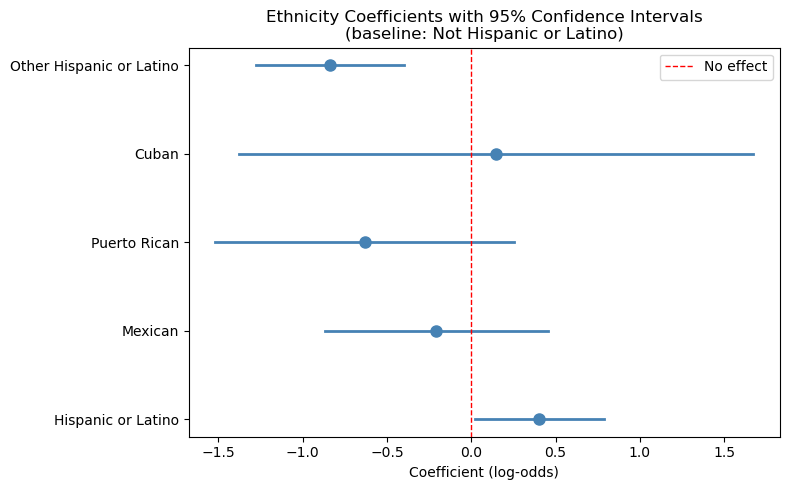

In [148]:
# Pull coefficients and confidence intervals for ethnicity variables
ethnicity_vars = ['ae_values_1', 'ae_values_11', 'ae_values_12', 'ae_values_13', 'ae_values_14']
labels = ['Hispanic or Latino', 'Mexican', 'Puerto Rican', 'Cuban', 'Other Hispanic or Latino']

coefs = res_ae.params[ethnicity_vars]
conf = res_ae.conf_int().loc[ethnicity_vars]

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    ax.plot([conf.loc[var, 0], conf.loc[var, 1]], [i, i], color='steelblue', linewidth=2)
    ax.plot(coefs[var], i, 'o', color='steelblue', markersize=8)

# Reference line at zero
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='No effect')

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Ethnicity Coefficients with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')
ax.legend()
plt.tight_layout()
plt.savefig('../images/ae_coefs_w_95perct_conf_int_baseline_not_hispanic_w_loan_type.png', bbox_inches='tight')
plt.show()

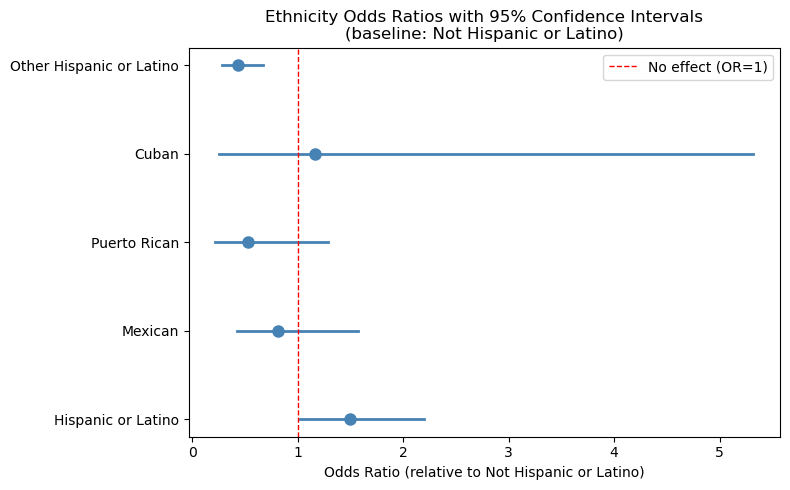

In [149]:
fig, ax = plt.subplots(figsize=(8, 5))

# Convert to odds ratios
coefs_or = np.exp(coefs)
conf_or = np.exp(conf)

for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    ax.plot([conf_or.loc[var, 0], conf_or.loc[var, 1]], [i, i], color='steelblue', linewidth=2)
    ax.plot(coefs_or[var], i, 'o', color='steelblue', markersize=8)

# Reference line at 1 instead of 0
ax.axvline(1, color='red', linestyle='--', linewidth=1, label='No effect (OR=1)')

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Odds Ratio (relative to Not Hispanic or Latino)')
ax.set_title('Ethnicity Odds Ratios with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')
ax.legend()
plt.tight_layout()
plt.savefig('../images/ae_odds_ratios_w_95perct_conf_int_baseline_not_hispanic_w_loan_type.png', bbox_inches='tight')
plt.show()

##### Control for Financial Factors, EXcluding loan_type

In [150]:
# loan_type
# Description: The type of covered loan or application
# Values:
# 1 - Conventional (not insured or guaranteed by FHA, VA, RHS, or FSA)
# 2 - Federal Housing Administration insured (FHA)
# 3 - Veterans Affairs guaranteed (VA)
# 4 - USDA Rural Housing Service or Farm Service Agency guaranteed (RHS or FSA)

In [151]:
model_logit_ae_nlt = smf.logit(formula = """
                                        approved_originated_or_denied ~ 
                                            ae_values_1 + ae_values_11 + ae_values_12 + ae_values_13 + ae_values_14 + 
                                            income + C(debt_to_income_ratio) + loan_to_value_ratio +
                                            tract_minority_population_percent""", data=hmda_ohe_all)

In [152]:
res_ae_nlt = model_logit_ae_nlt.fit()#maxiter=200

Optimization terminated successfully.
         Current function value: 0.318193
         Iterations 7


In [153]:
res_ae_nlt.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 Logit Regression Results                                
=========================================================================================
Dep. Variable:     approved_originated_or_denied   No. Observations:                 8595
Model:                                     Logit   Df Residuals:                     8568
Method:                                      MLE   Df Model:                           26
Date:                           Mon, 29 Jun 2026   Pseudo R-squ.:                  0.1470
Time:                                   22:13:43   Log-Likelihood:                -2734.9
converged:                                  True   LL-Null:                       -3206.3
Covariance Type:                       nonrobust   LLR p-value:                4.569e-182
=======================================================================================================
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                               3.9385      0.299     13.183      0.000       3.353       4.524
C(debt_to_income_ratio)[T.30%-<36%]    -0.0091      0.148     -0.061      0.951      -0.300       0.282
C(debt_to_income_ratio)[T.36]           0.2567      0.258      0.997      0.319      -0.248       0.762
C(debt_to_income_ratio)[T.37]           0.2658      0.258      1.032      0.302      -0.239       0.771
C(debt_to_income_ratio)[T.38]           0.1003      0.245      0.410      0.682      -0.379       0.580
C(debt_to_income_ratio)[T.39]           0.1853      0.249      0.745      0.456      -0.302       0.673
C(debt_to_income_ratio)[T.40]           0.1197      0.237      0.505      0.614      -0.345       0.585
C(debt_to_income_ratio)[T.41]           0.3690      0.248      1.491      0.136      -0.116       0.854
C(debt_to_income_ratio)[T.42]          -0.0693      0.217     -0.319      0.750      -0.495       0.356
C(debt_to_income_ratio)[T.43]           0.0897      0.220      0.408      0.683      -0.341       0.521
C(debt_to_income_ratio)[T.44]           0.1509      0.219      0.689      0.491      -0.278       0.580
C(debt_to_income_ratio)[T.45]           0.0851      0.215      0.396      0.692      -0.336       0.506
C(debt_to_income_ratio)[T.46]          -0.1552      0.222     -0.700      0.484      -0.590       0.279
C(debt_to_income_ratio)[T.47]          -0.2873      0.211     -1.360      0.174      -0.702       0.127
C(debt_to_income_ratio)[T.48]          -0.3167      0.199     -1.591      0.112      -0.707       0.073
C(debt_to_income_ratio)[T.49]          -0.0804      0.191     -0.420      0.674      -0.455       0.295
C(debt_to_income_ratio)[T.50%-60%]     -0.6879      0.143     -4.820      0.000      -0.968      -0.408
C(debt_to_income_ratio)[T.<20%]        -1.2065      0.178     -6.773      0.000      -1.556      -0.857
C(debt_to_income_ratio)[T.>60%]        -5.3686      0.380    -14.137      0.000      -6.113      -4.624
ae_values_1                             0.3488      0.194      1.796      0.073      -0.032       0.730
ae_values_11                           -0.1577      0.335     -0.471      0.638      -0.815       0.499
ae_values_12                           -0.5808      0.450     -1.292      0.196      -1.462       0.300
ae_values_13                            0.1759      0.776      0.227      0.821      -1.345       1.696
ae_values_14                           -0.7983      0.223     -3.573      0.000      -1.236      -0.360
income                                  0.0006      0.000      1.489      0.136      -0.000       0.001
loan_to_value_ratio                    -0.0156      0.003     -5.017      0.000      -0.022      -0.010
tract_minority_population_percent      -0.0058      0.001     -4.048      0.000      -0.009      -0.003
======================

In [154]:
np.exp(res_ae_nlt.params[['ae_values_1','ae_values_11','ae_values_12','ae_values_13','ae_values_14']])

ae_values_1     1.417390
ae_values_11    0.854104
ae_values_12    0.559455
ae_values_13    1.192282
ae_values_14    0.450087
dtype: float64

##### STATISTICAL ANALYSIS

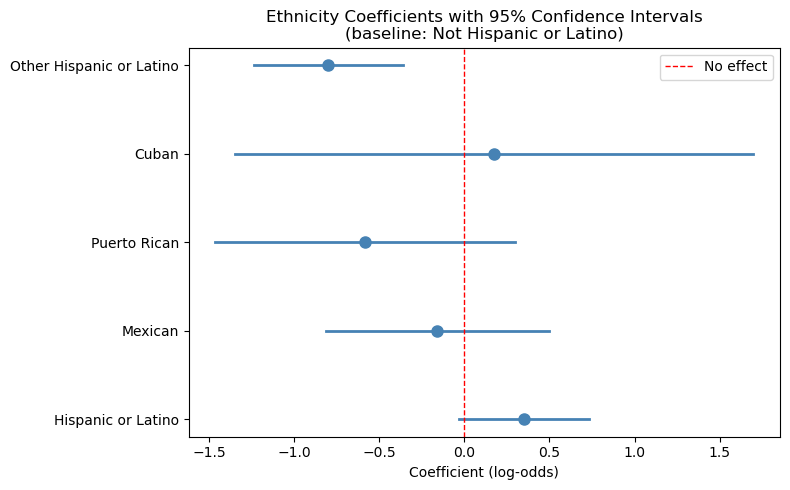

In [155]:
# pull coefficients and confidence intervals for ethnicity variables
ethnicity_vars = ['ae_values_1', 'ae_values_11', 'ae_values_12', 'ae_values_13', 'ae_values_14']
labels = ['Hispanic or Latino', 'Mexican', 'Puerto Rican', 'Cuban', 'Other Hispanic or Latino']

coefs_nlt = res_ae_nlt.params[ethnicity_vars]
conf_nlt = res_ae_nlt.conf_int().loc[ethnicity_vars]

# plot
fig, ax = plt.subplots(figsize=(8, 5))

for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    ax.plot([conf_nlt.loc[var, 0], conf_nlt.loc[var, 1]], [i, i], color='steelblue', linewidth=2)
    ax.plot(coefs_nlt[var], i, 'o', color='steelblue', markersize=8)

# reference line at zero
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='No effect')

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Ethnicity Coefficients with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')
ax.legend()
plt.tight_layout()
plt.savefig('../images/ae_coefs_w_95perct_conf_int_baseline_not_hispanic_wo_loan_type.png', bbox_inches='tight')
plt.show()

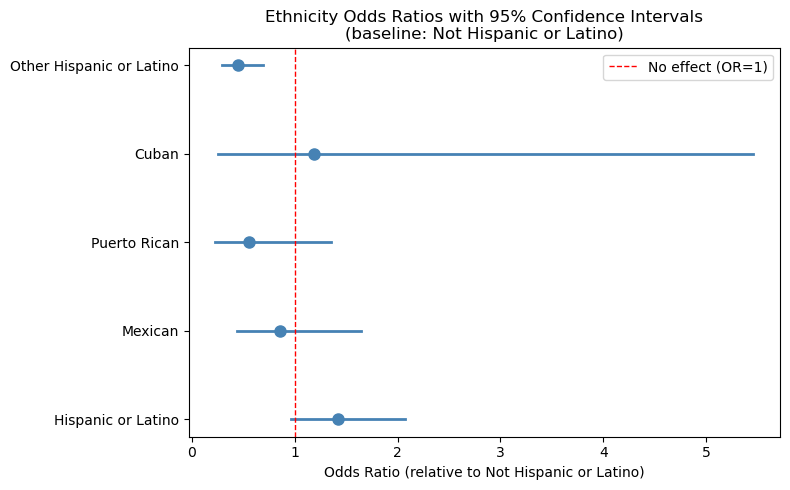

In [172]:
fig, ax = plt.subplots(figsize=(8, 5))

# Convert to odds ratios
coefs_or = np.exp(coefs_nlt)
conf_or = np.exp(conf_nlt)

for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    ax.plot([conf_or.loc[var, 0], conf_or.loc[var, 1]], [i, i], color='steelblue', linewidth=2)
    ax.plot(coefs_or[var], i, 'o', color='steelblue', markersize=8)

# Reference line at 1 instead of 0
ax.axvline(1, color='red', linestyle='--', linewidth=1, label='No effect (OR=1)')

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Odds Ratio (relative to Not Hispanic or Latino)')
ax.set_title('Ethnicity Odds Ratios with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')
ax.legend()
plt.tight_layout()
plt.savefig('../images/ae_odds_ratios_w_95perct_conf_int_baseline_not_hispanic_wo_loan_type.png', bbox_inches='tight')
plt.show()

#### Create an Hispanic vs. Not Hispanci Scenario

In [173]:
# applicant_ethnicity-1
# Description: Ethnicity of the applicant or borrower
# Values:
# 1 - Hispanic or Latino
# 11 - Mexican
# 12 - Puerto Rican
# 13 - Cuban
# 14 - Other Hispanic or Latino
# 2 - Not Hispanic or Latino
# 3 - Information not provided by applicant in mail, internet, or telephone application
# 4 - Not applicable

In [177]:
# rop rows where ethnicity info wasn't provided or not applicable
hdma_hispanic_not_hispanic = hmda_ohe_all[~hmda_ohe_all['applicant_ethnicity-1'].isin([3, 4])].copy()

In [178]:
# HMDA source columns
ethnicity_cols = ['applicant_ethnicity-1', 'applicant_ethnicity-2', 'applicant_ethnicity-3',
                  'applicant_ethnicity-4', 'applicant_ethnicity-5']

hispanic_codes = [1, 11, 12, 13, 14]

# indicator columns for each hispanic subcategory --> one per code
for code in hispanic_codes:
    hdma_hispanic_not_hispanic[f'ae_values_{code}'] = (hdma_hispanic_not_hispanic[ethnicity_cols] == code).any(axis=1)

# overall hispanic indicator
hdma_hispanic_not_hispanic['is_hispanic'] = hdma_hispanic_not_hispanic[[f'ae_values_{code}' for code in hispanic_codes]].any(axis=1)

# not hispanic indicator
hdma_hispanic_not_hispanic['not_hispanic'] = ~hdma_hispanic_not_hispanic['is_hispanic']

In [179]:
print(hdma_hispanic_not_hispanic['is_hispanic'].value_counts())
print(hdma_hispanic_not_hispanic['not_hispanic'].value_counts())

is_hispanic
False    7320
True      773
Name: count, dtype: int64
not_hispanic
True     7320
False     773
Name: count, dtype: int64


In [188]:
# compare to your original full dataset before filtering
print(hmda_ohe_all['applicant_ethnicity-1'].value_counts())

# check what got dropped
print((hmda_ohe_all['applicant_ethnicity-1'].isin([3, 4])).sum())

applicant_ethnicity-1
2.0     7343
3.0     2072
1.0      685
14.0      51
11.0       9
12.0       4
13.0       1
Name: count, dtype: int64
2072


In [189]:
hdma_hispanic_not_hispanic

,activity_year,lei,derived_msa-md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,dr_values_2,dr_values_3,dr_values_4,dr_values_5,dr_values_6,dr_values_7,dr_values_9,dr_values_10,is_hispanic,not_hispanic
0,2022,549300FGXN1K3HLB1R50,12060,GA,13067.0,1.306703e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,0,0,0,1,False,True
3,2022,549300FGXN1K3HLB1R50,12060,GA,13223.0,1.322312e+10,C,FHA:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,0,0,0,1,False,True
4,2022,549300FGXN1K3HLB1R50,12060,GA,13121.0,1.312101e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,0,0,0,1,False,True
5,2022,549300FGXN1K3HLB1R50,12060,GA,13117.0,1.311713e+10,C,VA:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,0,0,0,1,False,True
6,2022,549300FGXN1K3HLB1R50,12060,GA,13135.0,1.313505e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,0,0,0,1,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10160,2022,549300FGXN1K3HLB1R50,12060,GA,13067.0,1.306703e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,0,0,0,1,False,True
10161,2022,549300FGXN1K3HLB1R50,12060,GA,13067.0,1.306703e+10,C,VA:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,0,0,0,1,False,True
10162,2022,549300FGXN1K3HLB1R50,12060,GA,13117.0,1.311713e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,0,0,0,1,False,True
10163,2022,549300FGXN1K3HLB1R50,12060,GA,13121.0,1.312101e+10,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,0,0,0,0,0,0,0,1,False,True


In [183]:
model_logit_ae_h = smf.logit(formula = """
                                        approved_originated_or_denied ~ 
                                            is_hispanic + income + C(debt_to_income_ratio) + loan_to_value_ratio +
                                            tract_minority_population_percent""", data=hdma_hispanic_not_hispanic)

In [184]:
res_ae_h = model_logit_ae_h.fit()#maxiter=200

Optimization terminated successfully.
         Current function value: 0.317621
         Iterations 7


In [185]:
res_ae_h.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 Logit Regression Results                                
=========================================================================================
Dep. Variable:     approved_originated_or_denied   No. Observations:                 6934
Model:                                     Logit   Df Residuals:                     6911
Method:                                      MLE   Df Model:                           22
Date:                           Mon, 29 Jun 2026   Pseudo R-squ.:                  0.1309
Time:                                   22:37:51   Log-Likelihood:                -2202.4
converged:                                  True   LL-Null:                       -2534.1
Covariance Type:                       nonrobust   LLR p-value:                3.905e-126
=======================================================================================================
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                               4.1354      0.341     12.124      0.000       3.467       4.804
is_hispanic[T.True]                    -0.0850      0.129     -0.661      0.509      -0.337       0.167
C(debt_to_income_ratio)[T.30%-<36%]     0.0360      0.164      0.219      0.826      -0.286       0.358
C(debt_to_income_ratio)[T.36]           0.2654      0.280      0.947      0.344      -0.284       0.815
C(debt_to_income_ratio)[T.37]           0.2641      0.287      0.919      0.358      -0.299       0.827
C(debt_to_income_ratio)[T.38]           0.1562      0.281      0.555      0.579      -0.395       0.708
C(debt_to_income_ratio)[T.39]           0.1610      0.269      0.598      0.550      -0.367       0.689
C(debt_to_income_ratio)[T.40]           0.0123      0.251      0.049      0.961      -0.480       0.505
C(debt_to_income_ratio)[T.41]           0.3558      0.274      1.300      0.193      -0.181       0.892
C(debt_to_income_ratio)[T.42]          -0.1619      0.232     -0.697      0.486      -0.617       0.293
C(debt_to_income_ratio)[T.43]           0.1777      0.247      0.720      0.471      -0.306       0.661
C(debt_to_income_ratio)[T.44]           0.2860      0.246      1.162      0.245      -0.196       0.768
C(debt_to_income_ratio)[T.45]           0.1090      0.234      0.466      0.641      -0.349       0.567
C(debt_to_income_ratio)[T.46]           0.1581      0.265      0.597      0.551      -0.361       0.678
C(debt_to_income_ratio)[T.47]          -0.1538      0.240     -0.641      0.522      -0.624       0.317
C(debt_to_income_ratio)[T.48]          -0.2686      0.222     -1.211      0.226      -0.703       0.166
C(debt_to_income_ratio)[T.49]          -0.1618      0.207     -0.780      0.435      -0.568       0.245
C(debt_to_income_ratio)[T.50%-60%]     -0.5834      0.159     -3.662      0.000      -0.896      -0.271
C(debt_to_income_ratio)[T.<20%]        -1.2378      0.196     -6.303      0.000      -1.623      -0.853
C(debt_to_income_ratio)[T.>60%]        -5.2878      0.437    -12.096      0.000      -6.145      -4.431
income                                  0.0004      0.000      0.951      0.341      -0.000       0.001
loan_to_value_ratio                    -0.0183      0.004     -5.114      0.000      -0.025      -0.011
tract_minority_population_percent      -0.0051      0.002     -3.211      0.001      -0.008      -0.002
=======================================================================================================
"""

In [191]:
np.exp(res_ae_h.params[['is_hispanic[T.True]']])

is_hispanic[T.True]    0.918554
dtype: float64

##### STATISTICAL ANALYSIS

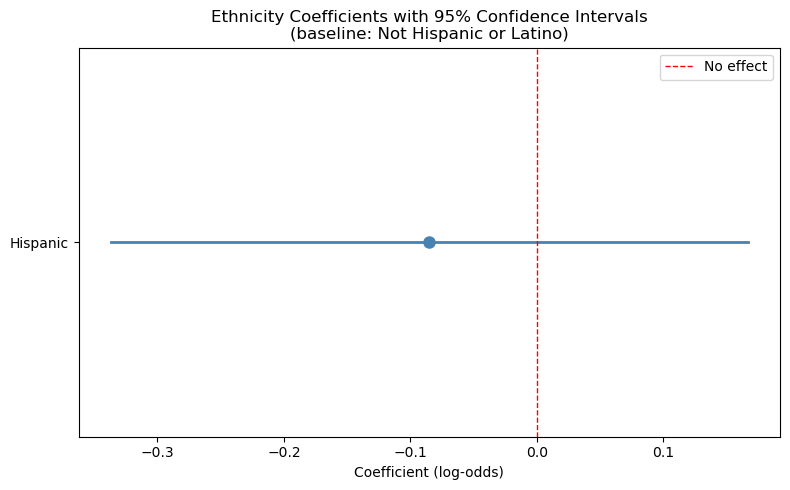

In [195]:
# pull coefficients and confidence intervals for ethnicity variables
ethnicity_vars = ['is_hispanic[T.True]']
labels = ['Hispanic']

coefs_h = res_ae_h.params[ethnicity_vars]
conf_h = res_ae_h.conf_int().loc[ethnicity_vars]

# plot
fig, ax = plt.subplots(figsize=(8, 5))

for i, (var, label) in enumerate(zip(ethnicity_vars, labels)):
    ax.plot([conf_h.loc[var, 0], conf_h.loc[var, 1]], [i, i], color='steelblue', linewidth=2)
    ax.plot(coefs_h[var], i, 'o', color='steelblue', markersize=8)

# reference line at zero
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='No effect')

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Ethnicity Coefficients with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')
ax.legend()
plt.tight_layout()
plt.savefig('../images/ae_h_coefs_w_95perct_conf_int_baseline_not_hispanic.png', bbox_inches='tight')
plt.show()

### Applicant Race

In [157]:
# applicant_race-1
# Description: Race of the applicant or borrower
# Values: 
# 1 - American Indian or Alaska Native
# 2 - Asian
# 21 - Asian Indian
# 22 - Chinese
# 23 - Filipino
# 24 - Japanese
# 25 - Korean
# 26 - Vietnamese
# 27 - Other Asian
# 3 - Black or African American
# 4 - Native Hawaiian or Other Pacific Islander
# 41 - Native Hawaiian
# 42 - Guamanian or Chamorro
# 43 - Samoan
# 44 - Other Pacific Islander
# 5 - White
# 6 - Information not provided by applicant in mail, internet, or telephone application
# 7 - Not applicable

#### Model for Applicant Race

##### Control for Financial Factors, excluding loan_type

In [158]:
model_logit_ar = smf.logit(formula = """approved_originated_or_denied ~ 
                                            ar_values_1 + ar_values_2 + ar_values_3 + ar_values_4 + ar_values_6 + 
                                            ar_values_21 + ar_values_22 + ar_values_23 + ar_values_24 + 
                                            ar_values_25 + ar_values_26 + ar_values_27 + ar_values_42 + 
                                            income + C(debt_to_income_ratio) + loan_to_value_ratio +
                                            tract_minority_population_percent""", data=hmda_ohe_all)

In [159]:
res_ar = model_logit_ar.fit()#maxiter=200

Optimization terminated successfully.
         Current function value: 0.317341
         Iterations 7


In [160]:
res_ar.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 Logit Regression Results                                
=========================================================================================
Dep. Variable:     approved_originated_or_denied   No. Observations:                 8595
Model:                                     Logit   Df Residuals:                     8560
Method:                                      MLE   Df Model:                           34
Date:                           Mon, 29 Jun 2026   Pseudo R-squ.:                  0.1493
Time:                                   22:13:45   Log-Likelihood:                -2727.5
converged:                                  True   LL-Null:                       -3206.3
Covariance Type:                       nonrobust   LLR p-value:                4.383e-179
=======================================================================================================
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                               3.8040      0.302     12.578      0.000       3.211       4.397
C(debt_to_income_ratio)[T.30%-<36%]     0.0143      0.149      0.096      0.923      -0.277       0.306
C(debt_to_income_ratio)[T.36]           0.2838      0.258      1.100      0.271      -0.222       0.789
C(debt_to_income_ratio)[T.37]           0.2952      0.258      1.145      0.252      -0.210       0.801
C(debt_to_income_ratio)[T.38]           0.1762      0.245      0.718      0.473      -0.305       0.657
C(debt_to_income_ratio)[T.39]           0.2144      0.249      0.861      0.389      -0.274       0.702
C(debt_to_income_ratio)[T.40]           0.1414      0.238      0.595      0.552      -0.324       0.607
C(debt_to_income_ratio)[T.41]           0.4027      0.248      1.624      0.104      -0.083       0.889
C(debt_to_income_ratio)[T.42]          -0.0331      0.218     -0.152      0.879      -0.460       0.394
C(debt_to_income_ratio)[T.43]           0.0995      0.220      0.451      0.652      -0.333       0.532
C(debt_to_income_ratio)[T.44]           0.1675      0.219      0.764      0.445      -0.262       0.597
C(debt_to_income_ratio)[T.45]           0.1107      0.215      0.515      0.607      -0.311       0.532
C(debt_to_income_ratio)[T.46]          -0.1125      0.222     -0.506      0.613      -0.548       0.323
C(debt_to_income_ratio)[T.47]          -0.2154      0.212     -1.015      0.310      -0.631       0.200
C(debt_to_income_ratio)[T.48]          -0.2757      0.200     -1.381      0.167      -0.667       0.116
C(debt_to_income_ratio)[T.49]          -0.0583      0.192     -0.303      0.762      -0.435       0.318
C(debt_to_income_ratio)[T.50%-60%]     -0.6128      0.145     -4.236      0.000      -0.896      -0.329
C(debt_to_income_ratio)[T.<20%]        -1.1916      0.179     -6.666      0.000      -1.542      -0.841
C(debt_to_income_ratio)[T.>60%]        -5.3208      0.383    -13.875      0.000      -6.072      -4.569
ar_values_1                            -0.7676      0.405     -1.894      0.058      -1.562       0.027
ar_values_2                            -0.0927      0.260     -0.357      0.721      -0.602       0.417
ar_values_3                            -0.4208      0.100     -4.197      0.000      -0.617      -0.224
ar_values_4                             1.6072      1.864      0.862      0.389      -2.046       5.261
ar_values_6                            -0.3053      0.106     -2.888      0.004      -0.513      -0.098
ar_values_21                           -0.1238      0.269     -0.461      0.645      -0.650       0.403
ar_values_22                           -0.2472      0.406     -0.609      0.543      -1.043       0.549
ar_values_23                            0.5047      1.057      0.477      0.633      -1.567       2.577
ar_values_24          

In [161]:
np.exp(res_ar.params[['ar_values_1', 'ar_values_2', 'ar_values_3', 
                      'ar_values_4', 'ar_values_6', 'ar_values_21', 
                      'ar_values_22', 'ar_values_23', 'ar_values_24', 
                      'ar_values_25', 'ar_values_26', 'ar_values_27', 'ar_values_42']])

ar_values_1     0.464103
ar_values_2     0.911440
ar_values_3     0.656535
ar_values_4     4.989024
ar_values_6     0.736909
ar_values_21    0.883561
ar_values_22    0.780967
ar_values_23    1.656544
ar_values_24    0.436359
ar_values_25    1.125051
ar_values_26    1.321337
ar_values_27    1.513058
ar_values_42    0.927314
dtype: float64

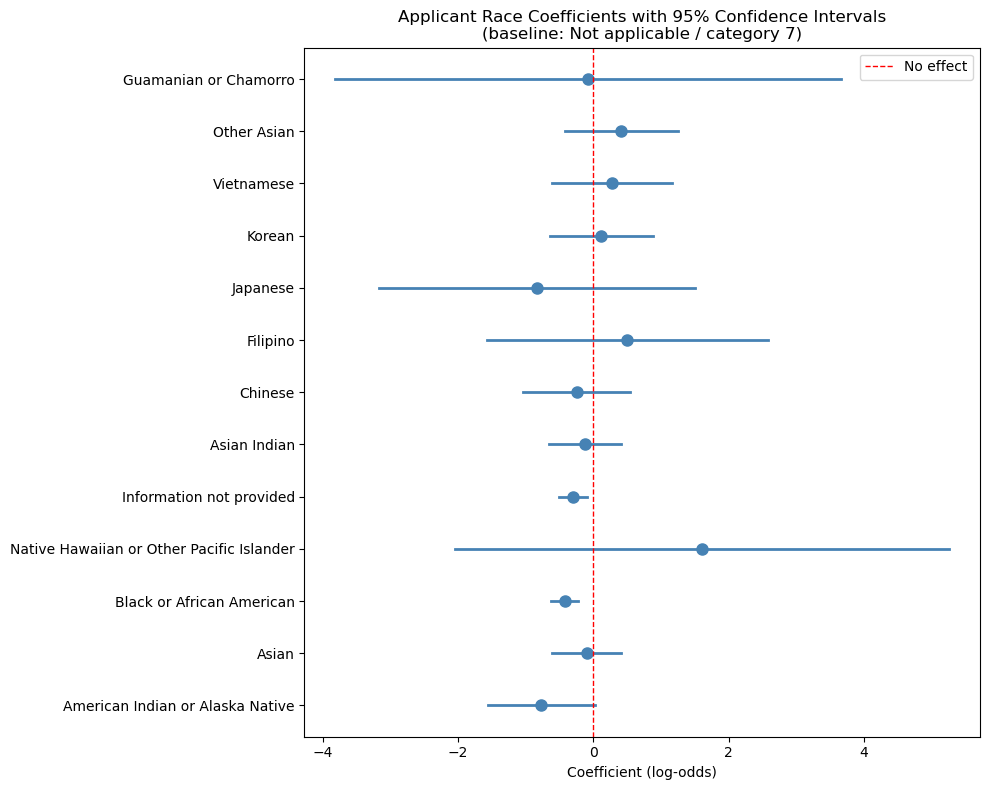

In [162]:
# Exclude variables which are closely correlated with one another (perfect separation) from plot
plot_vars = [
    'ar_values_1', 'ar_values_2', 'ar_values_3', 'ar_values_4', 'ar_values_6',
    'ar_values_21', 'ar_values_22', 'ar_values_23', 'ar_values_24', 'ar_values_25', 'ar_values_26', 'ar_values_27',
    'ar_values_42'
]

plot_labels = [
    'American Indian or Alaska Native',
    'Asian',
    'Black or African American',
    'Native Hawaiian or Other Pacific Islander',
    'Information not provided',
    'Asian Indian',
    'Chinese',
    'Filipino',
    'Japanese',
    'Korean',
    'Vietnamese',
    'Other Asian',
    'Guamanian or Chamorro'
]

coefs_ar_plot = res_ar.params[plot_vars]
conf_ar_plot = res_ar.conf_int().loc[plot_vars]

fig, ax = plt.subplots(figsize=(10, 8))

for i, (var, label) in enumerate(zip(plot_vars, plot_labels)):
    ax.plot([conf_ar_plot.loc[var, 0], conf_ar_plot.loc[var, 1]], [i, i], color='steelblue', linewidth=2)
    ax.plot(coefs_ar_plot[var], i, 'o', color='steelblue', markersize=8)

ax.axvline(0, color='red', linestyle='--', linewidth=1, label='No effect')
ax.set_yticks(range(len(plot_labels)))
ax.set_yticklabels(plot_labels)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Applicant Race Coefficients with 95% Confidence Intervals\n(baseline: Not applicable / category 7)')
ax.legend()
plt.tight_layout()
plt.savefig('../images/ar_coefs_w_95perct_conf_int_baseline_white.png', bbox_inches='tight')
plt.show()

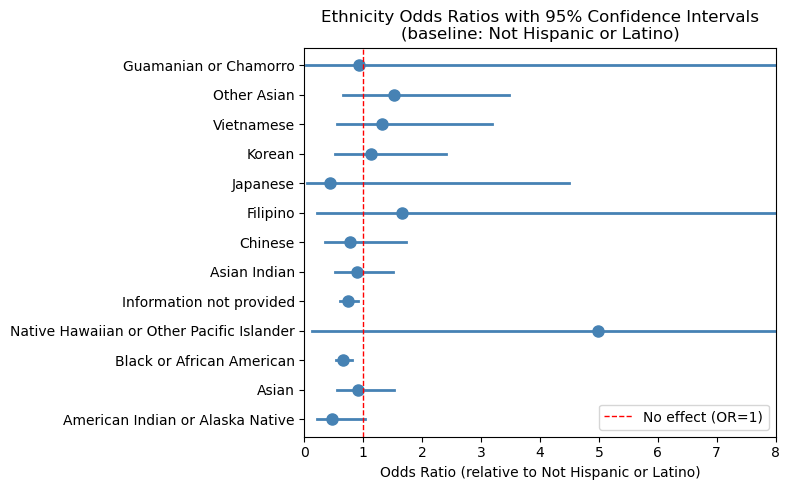

In [163]:
fig, ax = plt.subplots(figsize=(8, 5))

# Convert to odds ratios
coefs_or = np.exp(coefs_ar_plot)
conf_or = np.exp(conf_ar_plot)

for i, (var, label) in enumerate(zip(plot_vars, plot_labels)):
    ax.plot([conf_or.loc[var, 0], conf_or.loc[var, 1]], [i, i], color='steelblue', linewidth=2)
    ax.plot(coefs_or[var], i, 'o', color='steelblue', markersize=8)

# Reference line at 1 instead of 0
ax.axvline(1, color='red', linestyle='--', linewidth=1, label='No effect (OR=1)')

ax.set_yticks(range(len(plot_labels)))
ax.set_yticklabels(plot_labels)
ax.set_xlabel('Odds Ratio (relative to Not Hispanic or Latino)')
ax.set_title('Ethnicity Odds Ratios with 95% Confidence Intervals\n(baseline: Not Hispanic or Latino)')
ax.legend()
ax.set_xlim(0, 8)
plt.tight_layout()
plt.savefig('../images/ar_odds_ratios_w_95perct_conf_int_baseline_white_wo_loan_type.png', bbox_inches='tight')
plt.show()

### Gender

In [164]:
# applicant_sex
# Description: Sex of the applicant or borrower
# Values:
# 1 - Male
# 2 - Female
# 3 - Information not provided by applicant in mail, internet, or telephone application
# 4 - Not applicable
# 6 - Applicant selected both male and female

In [165]:
# See the value counts for each
print(hmda_ohe_all['applicant_sex'].value_counts())
print(hmda_ohe_all['applicant_sex_observed'].value_counts())

# Find mismatches
mismatch = hmda_ohe_all[hmda_ohe_all['applicant_sex'] != hmda_ohe_all['applicant_sex_observed']]
print(mismatch.shape)
print(mismatch[['applicant_sex', 'applicant_sex_observed']].value_counts())

applicant_sex
1    5523
2    3419
3    1219
6       4
Name: count, dtype: int64
applicant_sex_observed
2    10076
3       69
1       20
Name: count, dtype: int64
(6757, 166)
applicant_sex  applicant_sex_observed
1              2                         5473
3              2                         1211
1              3                           38
2              3                           23
               1                            8
6              2                            4
Name: count, dtype: int64


While it could be a data entry error or mortgage brokers making incorrect visual assumptions...

#### Holding constant Single Family Home, Income, and Debt to Income Ratio: this is a model for Applicant Ethnicity

In [166]:
model_logit_ae_sid = smf.logit(formula = """approved_originated_or_denied ~ 
                                                income + debt_to_income_ratio + ae_values_1 + ae_values_11 + 
                                                ae_values_12 + ae_values_13 + ae_values_14""", data=hmda_ohe_all)

In [167]:
res_ae_sid = model_logit_ae_sid.fit()

Optimization terminated successfully.
         Current function value: 0.331477
         Iterations 7


In [168]:
res_ae_sid.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 Logit Regression Results                                
=========================================================================================
Dep. Variable:     approved_originated_or_denied   No. Observations:                10134
Model:                                     Logit   Df Residuals:                    10109
Method:                                      MLE   Df Model:                           24
Date:                           Mon, 29 Jun 2026   Pseudo R-squ.:                  0.1121
Time:                                   22:13:48   Log-Likelihood:                -3359.2
converged:                                  True   LL-Null:                       -3783.5
Covariance Type:                       nonrobust   LLR p-value:                1.090e-163
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                            2.1768      0.124     17.517      0.000       1.933       2.420
debt_to_income_ratio[T.30%-<36%]     0.0174      0.142      0.123      0.902      -0.261       0.295
debt_to_income_ratio[T.36]           0.2531      0.245      1.032      0.302      -0.227       0.734
debt_to_income_ratio[T.37]           0.1428      0.234      0.611      0.541      -0.315       0.601
debt_to_income_ratio[T.38]           0.2014      0.237      0.850      0.395      -0.263       0.666
debt_to_income_ratio[T.39]          -0.1449      0.212     -0.683      0.495      -0.561       0.271
debt_to_income_ratio[T.40]           0.1826      0.227      0.805      0.421      -0.262       0.627
debt_to_income_ratio[T.41]           0.1762      0.221      0.799      0.425      -0.256       0.609
debt_to_income_ratio[T.42]          -0.1673      0.198     -0.844      0.398      -0.556       0.221
debt_to_income_ratio[T.43]           0.1027      0.207      0.497      0.619      -0.303       0.508
debt_to_income_ratio[T.44]           0.0300      0.197      0.152      0.879      -0.357       0.417
debt_to_income_ratio[T.45]           0.0556      0.201      0.277      0.782      -0.338       0.449
debt_to_income_ratio[T.46]          -0.1425      0.205     -0.697      0.486      -0.543       0.258
debt_to_income_ratio[T.47]          -0.3380      0.194     -1.743      0.081      -0.718       0.042
debt_to_income_ratio[T.48]          -0.3386      0.184     -1.845      0.065      -0.698       0.021
debt_to_income_ratio[T.49]          -0.0845      0.179     -0.473      0.636      -0.435       0.266
debt_to_income_ratio[T.50%-60%]     -0.7033      0.130     -5.414      0.000      -0.958      -0.449
debt_to_income_ratio[T.<20%]        -1.1313      0.171     -6.620      0.000      -1.466      -0.796
debt_to_income_ratio[T.>60%]        -3.8052      0.197    -19.364      0.000      -4.190      -3.420
income                               0.0015      0.000      3.317      0.001       0.001       0.002
ae_values_1                          0.2582      0.178      1.451      0.147      -0.090       0.607
ae_values_11                        -0.0058      0.313     -0.018      0.985      -0.620       0.608
ae_values_12                        -0.2215      0.434     -0.511      0.610      -1.072       0.629
ae_values_13                        -0.1521      0.642     -0.237      0.813      -1.411       1.106
ae_values_14                        -0.7484      0.213     -3.515      0.000      -1.166      -0.331
====================================================================================================
"""

### Co-Applicant Ethnicity CAE

In [169]:
# co-applicant_ethnicity-1
# Description: Ethnicity of the first co-applicant or co-borrower
# Values:
# 1 - Hispanic or Latino
# 11 - Mexican
# 12 - Puerto Rican
# 13 - Cuban
# 14 - Other Hispanic or Latino
# 2 - Not Hispanic or Latino
# 3 - Information not provided by applicant in mail, internet, or telephone application
# 4 - Not applicable
# 5 - No co-applicant

In [170]:
model_logit_cae = smf.logit(formula = """approved_originated_or_denied ~ 
                                                cae_values_1 + cae_values_11 + cae_values_12 + 
                                                cae_values_13 + cae_values_14""", data=hmda_ohe_all)

In [171]:
res_cae = model_logit_cae.fit()

C:\Users\Cat\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
C:\Users\Cat\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


         Current function value: inf
         Iterations: 35


LinAlgError: Singular matrix

In [ ]:
res_cae.summary()

### Applicant Race

##### Removed (ar_values_5 : White), (ar_values_6 : Information not provided by applicant in mail, internet, or telephone application), (ar_values_7 : Not applicable).

In [ ]:
# applicant_race-1
# Description: Race of the applicant or borrower
# Values:
# 1 - American Indian or Alaska Native
# 2 - Asian
# 21 - Asian Indian
# 22 - Chinese
# 23 - Filipino
# 24 - Japanese
# 25 - Korean
# 26 - Vietnamese
# 27 - Other Asian
# 3 - Black or African American
# 4 - Native Hawaiian or Other Pacific Islander
# 41 - Native Hawaiian
# 42 - Guamanian or Chamorro
# 43 - Samoan
# 44 - Other Pacific Islander
# 5 - White
# 6 - Information not provided by applicant in mail, internet, or telephone application
# 7 - Not applicable


# list_of_values_to_keep = [1, 2, 3, 4, 21, 22, 23, 24, 25, 26, 27, 41, 42, 43, 44]

# hmda_ohe_dr_ar1test = hmda_ohe_dr[hmda_ohe_dr['applicant_race-1'].isin(list_of_values_to_keep)]
# hmda_ohe_dr_ar1test['applicant_race-1'].unique()

In [ ]:
model_logit_ar = smf.logit(formula = """approved_originated_or_denied ~ 
                                            ar_values_1 + ar_values_2 + ar_values_3 + ar_values_4 + ar_values_22 + 
                                            ar_values_23 + ar_values_24 + ar_values_25 + ar_values_26 + ar_values_27 + 
                                            ar_values_41 + ar_values_42 + ar_values_43 + ar_values_44""", data=hmda_ohe_all)

In [ ]:
res_ar = model_logit_ar.fit()

In [ ]:
res_ar.summary()

In [ ]:
hmda_ohe_all['negative_amortization'].unique()

In [ ]:
# column and dataset
data = hmda_ohe_all['reverse_mortgage']
df = hmda_ohe_all

# calculate percentages (normalize=True gives fractions, multiply by 100)
pct_df = (
    df['reverse_mortgage'].value_counts(normalize=True).reset_index(name="Percentage")
)
pct_df["Percentage"] *= 100

# plot the bar graph
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='reverse_mortgage', y="Percentage", data=pct_df, palette="viridis", legend=False)

# format y axis as percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# add percentage labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Percentage Distribution of reverse_mortgage")
plt.ylabel("Percentage")
plt.xlabel("aro")
plt.show()

In [ ]:
# column and dataset
data = hmda_ohe_all['applicant_race_observed']
df = hmda_ohe_all

# calculate percentages (normalize=True gives fractions, multiply by 100)
pct_df = (
    df['applicant_race_observed'].value_counts(normalize=True).reset_index(name="Percentage")
)
pct_df["Percentage"] *= 100

# plot the bar graph
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='applicant_race_observed', y="Percentage", data=pct_df, palette="viridis", legend=False)

# format y axis as percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# add percentage labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Percentage Distribution of aro")
plt.ylabel("Percentage")
plt.xlabel("aro")
plt.show()

In [ ]:
# column and dataset
data = hmda_ohe_all['other_nonamortizing_features']
df = hmda_ohe_all

# calculate percentages (normalize=True gives fractions, multiply by 100)
pct_df = (
    df['other_nonamortizing_features'].value_counts(normalize=True).reset_index(name="Percentage")
)
pct_df["Percentage"] *= 100

# plot the bar graph
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='other_nonamortizing_features', y="Percentage", data=pct_df, palette="viridis", legend=False)

# format y axis as percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# add percentage labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Percentage Distribution of ar")
plt.ylabel("Percentage")
plt.xlabel("onaf")
plt.show()

In [ ]:
# column and dataset
data = hmda_ohe_all['balloon_payment']
df = hmda_ohe_all

# calculate percentages (normalize=True gives fractions, multiply by 100)
pct_df = (
    df['balloon_payment'].value_counts(normalize=True).reset_index(name="Percentage")
)
pct_df["Percentage"] *= 100

# plot the bar graph
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='balloon_payment', y="Percentage", data=pct_df, palette="viridis", legend=False)

# format y axis as percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# add percentage labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Percentage Distribution of ar")
plt.ylabel("Percentage")
plt.xlabel("ar")
plt.show()



In [ ]:
# applicant_race-1
# Description: Race of the applicant or borrower
# Values:
# 1 - American Indian or Alaska Native
# 2 - Asian
# 21 - Asian Indian
# 22 - Chinese
# 23 - Filipino
# 24 - Japanese
# 25 - Korean
# 26 - Vietnamese
# 27 - Other Asian
# 3 - Black or African American
# 4 - Native Hawaiian or Other Pacific Islander
# 41 - Native Hawaiian
# 42 - Guamanian or Chamorro
# 43 - Samoan
# 44 - Other Pacific Islander
# 5 - White
# 6 - Information not provided by applicant in mail, internet, or telephone application
# 7 - Not applicable

list_of_values_to_keep = [1, 2, 3, 4, 21, 22, 23, 24, 25, 26, 27, 41, 42, 43, 44]

hmda_ohe_dr_ar1test = hmda_ohe_all[hmda_ohe_all['applicant_race-1'].isin(list_of_values_to_keep)]
hmda_ohe_dr_ar1test['applicant_race-1'].unique()

In [ ]:
# column and dataset
data = hmda_ohe_dr_ar1test['applicant_race-1']
df = hmda_ohe_dr_ar1test

# calculate percentages (normalize=True gives fractions, multiply by 100)
pct_df = (
    df['applicant_race-1'].value_counts(normalize=True).reset_index(name="Percentage")
)
pct_df["Percentage"] *= 100

# plot the bar graph
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='applicant_race-1', y="Percentage", data=pct_df, palette="viridis", legend=False)

# format y axis as percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# add percentage labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Percentage Distribution of ar")
plt.ylabel("Percentage")
plt.xlabel("ar")
plt.show()



### Applicant Ethnicity

In [ ]:
model_logit_ae = smf.logit(formula = """approved_originated_or_denied ~ 
                                            ae_values_1 + ae_values_3 + ae_values_11 + ae_values_12 + 
                                            ae_values_13 + ae_values_14""", data=hmda_ohe_all)

In [ ]:
res_ae = model_logit_ae.fit()

In [ ]:
res_ae.summary()